# Plot traces heatmap

- to get quick overview over all traces in the respective two conditions

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import datajoint as dj
import datetime
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import seaborn as sns

from djimaging.utils import plot_utils, math_utils, trace_utils

/workspace/.venv/lib/python3.12/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Access to djimaging database

## Define paths

In [3]:
username = !whoami
username = username[0]
username

'fsalomon'

In [4]:
home_directory = os.path.expanduser("~")
home_directory

'/gpfs01/euler/User/fsalomon'

In [5]:
# Path to djimaging
path_to_djimaging = f'{home_directory}/github/eulerlab/'

# Clone djimaging if you haven't downloaded it yet
# assert os.isdir(path_to_djimaging), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging} && git clone git@github.com:eulerlab/djimaging.git

# Install djimaging if not done yet
# assert os.isdir(os.path.join(path_to_djimaging, 'djimaging')), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging}/djimaging/ && sudo pip install -e .

## Prepare dj config

In [6]:
# Set config file
config_file = f'{home_directory}/GitHub/docker/dj_{username}_conf.json'
assert os.path.isfile(config_file), f'Set the path to your config file: {config_file}'

In [7]:
# Define a schema name or use the default name for your personal test schema
# It should start with ageuler and have some meaningful name after that
schema_name = f"ageuler_{username}_neuromodulation_ac"

In [8]:
# Do you want to use the RGC classifier?
# If so, make sure to add the respective tables into your schema.
use_rgc_classifier = True

if use_rgc_classifier:  # Define any existing outputfolder for the classifier to be saved
    output_folder = f'{home_directory}/datajoint/rgc_classifier'
    assert os.path.isdir(output_folder), f'Set path to output directory: {output_folder}'

In [9]:
# Load configuration for user
dj.config.load(config_file)
dj.config['schema_name'] = schema_name

if use_rgc_classifier:
    from djimaging.tables.classifier.rgc_classifier import prepare_dj_config_rgc_classifier
    prepare_dj_config_rgc_classifier(output_folder)

print("schema_name:", dj.config['schema_name'])
dj.conn()

[2025-11-04 14:50:49,214][INFO]: DataJoint is configured from /gpfs01/euler/User/fsalomon/GitHub/docker/dj_fsalomon_conf.json
[2025-11-04 14:50:49,466][INFO]: DataJoint 0.14.6 connected to fsalomon@172.25.240.200:3306


schema_name: ageuler_fsalomon_neuromodulation_ac


DataJoint connection (connected) fsalomon@172.25.240.200:3306

## Create or load schema

In [10]:
# Import your own schema, which defines the tables you will have in your database and how they are connected.
from djimaging.user.amacrine_cells_neuromodulation.schemas.amacrine_cells_neuromodulation_schema import *

In [11]:
if use_rgc_classifier:
    try:
        CelltypeAssignment()
    except Exception as e:
        import warnings
        warnings.warn("""
            If you want to include the RGC classifier in your database, you have to copy the respective tables from 
            djimaging/schemas/full_rgc_schema.py 
            to the schema you just imported (see above).
            Then restart the notebook and try again.
            """)

/tmp/ipykernel_10111/4275538225.py:6: UserWarning: 
            If you want to include the RGC classifier in your database, you have to copy the respective tables from 
            djimaging/schemas/full_rgc_schema.py 
            to the schema you just imported (see above).
            Then restart the notebook and try again.
            
  warnings.warn("""


## Important note

If the schema with the name `schema_name = f"ageuler_{username}_test"` already exists, it is important that the schema definition here is the same as it was when the schema was created.
If you did the other tutorial first, and did not delete (=drop) the schema afterwards, this will not be the case, for example.
Then you already have a schema with the same name but different tables, the first being based on the schema `rgc_classifier_schema`, and this one being based on `my_schema`. This can result in a variety of problems, so you either have to change the schema name here or drop the old schema first.

Outside of this tutorial, in most cases, you want exactly one schema per project to never run into this problem.

In [12]:
from djimaging.utils.dj_utils import activate_schema

activate_schema(schema=schema, create_schema=True, create_tables=True)
schema

Schema `ageuler_fsalomon_neuromodulation_ac`

## ERD

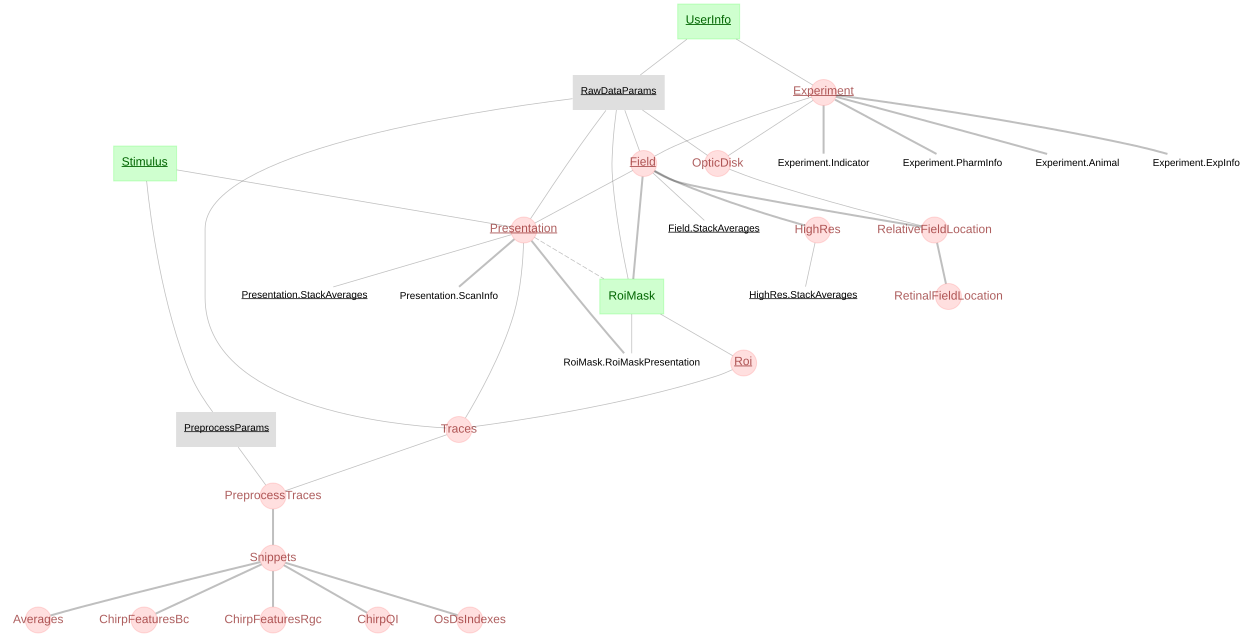

In [13]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    display(dj.ERD(schema))

# Global Chirp
## Plot Heatmaps

- previously in the workflow notebook for plotting heatmaps a function was defined to create heatmaps where the field is annotated

In [14]:
# Define date and stimulus
date = datetime.date(2025, 10, 23)
stimulus = "gChirp"

In [65]:
def plot_signals_heatmap_annotated_field(
    signals, ax=None, cb=True, vabsmax=None, symmetric=True,
    field_labels=None, field_colors=None, colorbar_width=0.03,
    legend=True, heatmap_colorbar_position=0.2
):
    """
    Plot a clean heatmap of signals with an optional color-coded bar for field annotations.

    Parameters
    ----------
    signals : array (n_rois, n_timepoints)
        The signal matrix to plot.
    ax : matplotlib axis, optional
        Axis to plot into.
    cb : bool
        Whether to add a colorbar for signal intensity.
    vabsmax : float
        Maximum absolute value for symmetric colormap scaling.
    symmetric : bool
        Whether to use symmetric color limits.
    field_labels : list of str, optional
        Field labels (e.g. 'XY1', 'XY2', ...) for each ROI (row).
    field_colors : dict, optional
        Mapping from field label -> color (e.g. {'XY1': 'red', 'XY2': 'blue', ...}).
        If None, automatically assigns colors.
    colorbar_width : float
        Fractional width of the color bar relative to main heatmap width.
    legend : bool
        Whether to show the legend mapping field colors.
    """
    n_rois, n_timepoints = signals.shape

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(4, n_rois * 0.03))
    fig = ax.figure  # always need figure for additional axes

    # Determine color limits
    if vabsmax is None:
        vabsmax = np.nanmax(np.abs(signals))

    if symmetric:
        vmin, vmax, cmap = -vabsmax, vabsmax, 'bwr'
    else:
        vmin, vmax, cmap = np.nanmin(signals), np.nanmax(signals), 'viridis'

    # Main heatmap
    im = ax.imshow(
        signals, aspect='auto', vmin=vmin, vmax=vmax, cmap=cmap,
        interpolation='none', origin='lower'
    )

    if cb:
        plt.colorbar(im, ax=ax, fraction=0.05, pad=heatmap_colorbar_position, anchor=(1.1, 0.5)) # fraction=0.046, pad=0.08, anchor=(200, 0.5)

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    # === Field color bar ===
    if field_labels is not None:
        field_labels = np.array(field_labels)

        unique_fields = np.unique(field_labels)
        if field_colors is None:
            cmap_fields = plt.get_cmap('tab10', len(unique_fields))
            field_colors = {f: cmap_fields(i) for i, f in enumerate(unique_fields)}

        # Build color bar as RGBA array
        color_bar = np.array([field_colors[f] for f in field_labels]).reshape(n_rois, 1, 4)

        # Create inset axis for the color bar
        bbox = ax.get_position()
        color_ax = fig.add_axes([
            bbox.x1 + colorbar_width * 0.5,
            bbox.y0,
            colorbar_width * 0.2,
            bbox.height
        ])
        color_ax.imshow(color_bar, aspect='auto', origin='lower')
        color_ax.set_xticks([])
        color_ax.set_yticks([])
        for spine in color_ax.spines.values():
            spine.set_visible(False)

        # Add legend (optional)
        if legend:
            legend_handles = [
                plt.Line2D([0], [0], color=field_colors[f], lw=6, label=f)
                for f in unique_fields
            ]
            ax.legend(
                handles=legend_handles, title="Field",
                bbox_to_anchor=(1.2, 1), loc='upper left', frameon=False
            )

    return ax

In [58]:
# Take chirp averages from 08.09.2025 + add quality index from same data
# To quickly filter for quality
gchirp_quality = (Averages() & {"date": date, "stim_name": stimulus}) * (ChirpQI() & {"date": date, "stim_name": stimulus})
gchirp_quality & "qidx > 0.3"

[2025-11-04 16:06:18,713][WARNING]: Reconnecting to MySQL server.


experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes,qidx quality index as signal to noise ratio,min_qidx minimum quality index as 1/r (r = #repetitions)
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,3,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.32174,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,4,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.348374,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,5,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.440524,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,6,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.312994,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,7,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.335758,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,8,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.335647,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,9,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.312693,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,10,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.381247,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,11,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.364955,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,12,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.317588,0.2


In [59]:
# Filter for C1, C2, and DETANO + qidx > 0.3
C1 = gchirp_quality & {"cond2": "C1"} & "qidx > 0.3"
C2 = gchirp_quality & {"cond2": "C2"} & "qidx > 0.3"
DETANO = gchirp_quality & {"cond2": "DETANO"} & "qidx > 0.3"

### C1 and C2

In [60]:
# Retrieve C1 recordings which also have a C2 recording
C1_and_C2 = C1 & (dj.U("field", "roi_id") & C2)
C1_and_C2

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes,qidx quality index as signal to noise ratio,min_qidx minimum quality index as 1/r (r = #repetitions)
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,3,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.32174,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,4,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.348374,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,6,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.312994,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,8,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.335647,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,10,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.381247,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,11,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.364955,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,12,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.317588,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,15,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.408226,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,17,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.503402,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C1,19,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.37285,0.2


In [61]:
# Retrieve C2 recordings which also have a C1 recording
C2_and_C1 = C2 & (dj.U("field", "roi_id") & C1)
C2_and_C1

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes,qidx quality index as signal to noise ratio,min_qidx minimum quality index as 1/r (r = #repetitions)
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C2,3,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.362893,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C2,4,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.340067,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C2,6,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.307102,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C2,8,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.319821,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C2,10,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.328852,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C2,11,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.365397,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C2,12,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.365603,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C2,15,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.314387,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C2,17,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.354132,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,gChirp,C2,19,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.330004,0.2


In [62]:
from djimaging.utils import plot_utils, math_utils, trace_utils

In [63]:
averages_norm_c1 = (C1_and_C2).fetch("average_norm")
averages_norm_c2 = (C2_and_C1).fetch("average_norm")

averages_norm_c1 = math_utils.padded_vstack(averages_norm_c1, cval=np.nan)
averages_norm_c2 = math_utils.padded_vstack(averages_norm_c2, cval=np.nan)

n = averages_norm_c1.shape[0]

sort = True

sort_idxs = trace_utils.argsort_traces(averages_norm_c1, ignore_nan=True) if sort else np.arange(n)

fields_c1 = (C1_and_C2).fetch("field")
fields_c2 = (C2_and_C1).fetch("field")

fields_c1_sorted = np.array(fields_c1)[sort_idxs]
fields_c2_sorted = np.array(fields_c2)[sort_idxs]

# fig, axs = plt.subplots(1, 2, figsize=(8, n * 0.03))

# plot_signals_heatmap_annotated_field(
#     signals=averages_norm_c1[sort_idxs, :],
#     ax=axs[0],
#     cb=False,
#     field_labels=fields_c1_sorted,
#     legend=False
# )

# plot_signals_heatmap_annotated_field(
#     signals=averages_norm_c2[sort_idxs, :],
#     ax=axs[1],
#     cb=True,
#     field_labels=fields_c2_sorted,
#     legend=True
# )

# axs[0].set_title("C1")
# axs[1].set_title("C2")

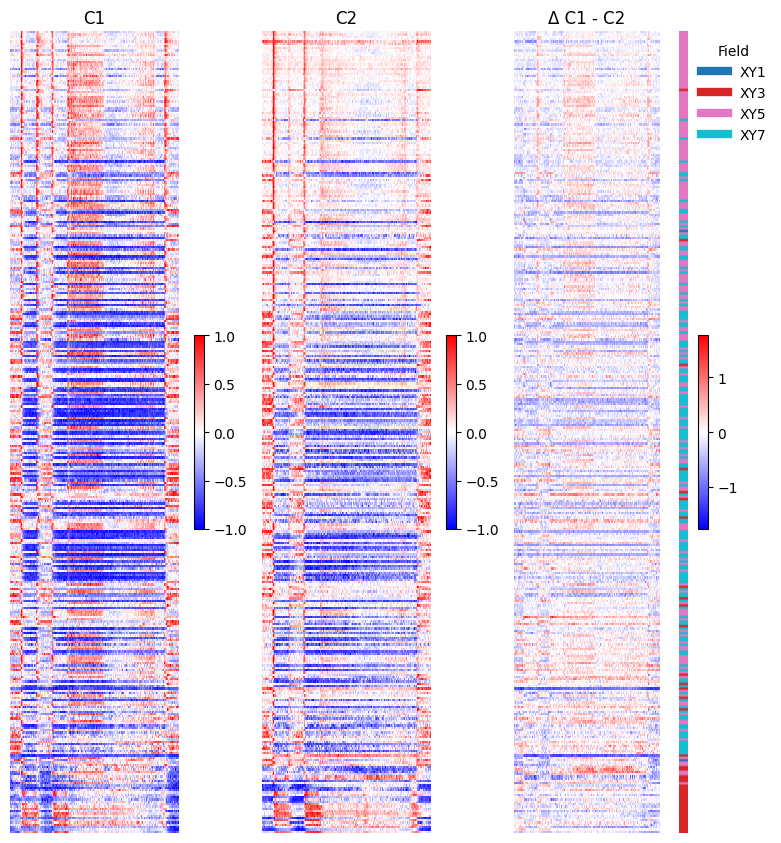

In [66]:
averages_norm_c1_minus_c2 = averages_norm_c1[sort_idxs, :] - averages_norm_c2[sort_idxs, :]

fig, axs = plt.subplots(1, 3, figsize=(9, n * 0.03))

plot_signals_heatmap_annotated_field(
    signals=averages_norm_c1[sort_idxs, :],
    ax=axs[0],
    cb=True,
    field_labels=None,
    legend=False,
    heatmap_colorbar_position=0.08
)

plot_signals_heatmap_annotated_field(
    signals=averages_norm_c2[sort_idxs, :],
    ax=axs[1],
    cb=True,
    field_labels=None,
    legend=False,
    heatmap_colorbar_position=0.08
)

plot_signals_heatmap_annotated_field(
    signals=averages_norm_c1_minus_c2,
    ax=axs[2],
    cb=True,
    field_labels=fields_c2_sorted,
    legend=True,
    colorbar_width=0.05,
    heatmap_colorbar_position=0.2
)

axs[0].set_title("C1")
axs[1].set_title("C2")
axs[2].set_title("Δ C1 - C2")

plt.subplots_adjust(wspace=0.3)

plt.savefig("plots/20251023/traces/heatmap_gchirp_c1_and_c2.png",
            dpi=300,
            bbox_inches="tight")

### C1 and DETA/NO

In [68]:
# Retrieve C1 recordings which also have a DETANO recording
C1_and_DETANO = C1 & (dj.U("field", "roi_id") & DETANO)
C1_and_DETANO

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes,qidx quality index as signal to noise ratio,min_qidx minimum quality index as 1/r (r = #repetitions)
Salomon,2025-10-23,1,1,XY8,LR,t,gChirp,C1,6,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.385905,0.2
Salomon,2025-10-23,1,1,XY8,LR,t,gChirp,C1,11,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.30506,0.2
Salomon,2025-10-23,1,1,XY8,LR,t,gChirp,C1,15,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.346152,0.2
Salomon,2025-10-23,1,1,XY8,LR,t,gChirp,C1,20,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.402512,0.2
Salomon,2025-10-23,1,1,XY8,LR,t,gChirp,C1,23,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.369559,0.2
Salomon,2025-10-23,1,1,XY8,LR,t,gChirp,C1,27,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.31045,0.2
Salomon,2025-10-23,1,1,XY8,LR,t,gChirp,C1,28,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.32731,0.2
Salomon,2025-10-23,1,1,XY8,LR,t,gChirp,C1,33,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.329235,0.2
Salomon,2025-10-23,1,1,XY8,LR,t,gChirp,C1,34,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.356987,0.2
Salomon,2025-10-23,1,1,XY8,LR,t,gChirp,C1,35,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.333044,0.2


In [69]:
# Retrieve DETANO recordings which also have a C1 recording
DETANO_and_C1 = DETANO & (dj.U("field", "roi_id") & C1)
DETANO_and_C1

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes,qidx quality index as signal to noise ratio,min_qidx minimum quality index as 1/r (r = #repetitions)
Salomon,2025-10-23,1,1,XY8,LR,t,gChirp,DETANO,6,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.54201,0.2
Salomon,2025-10-23,1,1,XY8,LR,t,gChirp,DETANO,11,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.450554,0.2
Salomon,2025-10-23,1,1,XY8,LR,t,gChirp,DETANO,15,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.4273,0.2
Salomon,2025-10-23,1,1,XY8,LR,t,gChirp,DETANO,20,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.489451,0.2
Salomon,2025-10-23,1,1,XY8,LR,t,gChirp,DETANO,23,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.549361,0.2
Salomon,2025-10-23,1,1,XY8,LR,t,gChirp,DETANO,27,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.395604,0.2
Salomon,2025-10-23,1,1,XY8,LR,t,gChirp,DETANO,28,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.346017,0.2
Salomon,2025-10-23,1,1,XY8,LR,t,gChirp,DETANO,33,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.473911,0.2
Salomon,2025-10-23,1,1,XY8,LR,t,gChirp,DETANO,34,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.315925,0.2
Salomon,2025-10-23,1,1,XY8,LR,t,gChirp,DETANO,35,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.476867,0.2


In [70]:
averages_norm_c1 = (C1_and_DETANO).fetch("average_norm")
averages_norm_detano = (DETANO_and_C1).fetch("average_norm")

averages_norm_c1 = math_utils.padded_vstack(averages_norm_c1, cval=np.nan)
averages_norm_detano = math_utils.padded_vstack(averages_norm_detano, cval=np.nan)

n = averages_norm_c1.shape[0]

sort = True

sort_idxs = trace_utils.argsort_traces(averages_norm_c1, ignore_nan=True) if sort else np.arange(n)

fields_c1 = (C1_and_DETANO).fetch("field")
fields_detano = (DETANO_and_C1).fetch("field")

fields_c1_sorted = np.array(fields_c1)[sort_idxs]
fields_detano_sorted = np.array(fields_detano)[sort_idxs]

# fig, axs = plt.subplots(1, 2, figsize=(8, n * 0.03))

# plot_signals_heatmap_annotated_field(
#     signals=averages_norm_c1[sort_idxs, :],
#     ax=axs[0],
#     cb=False,
#     field_labels=fields_c1_sorted,
#     legend=False
# )

# plot_signals_heatmap_annotated_field(
#     signals=averages_norm_c2[sort_idxs, :],
#     ax=axs[1],
#     cb=True,
#     field_labels=fields_c2_sorted,
#     legend=True
# )

# axs[0].set_title("C1")
# axs[1].set_title("C2")

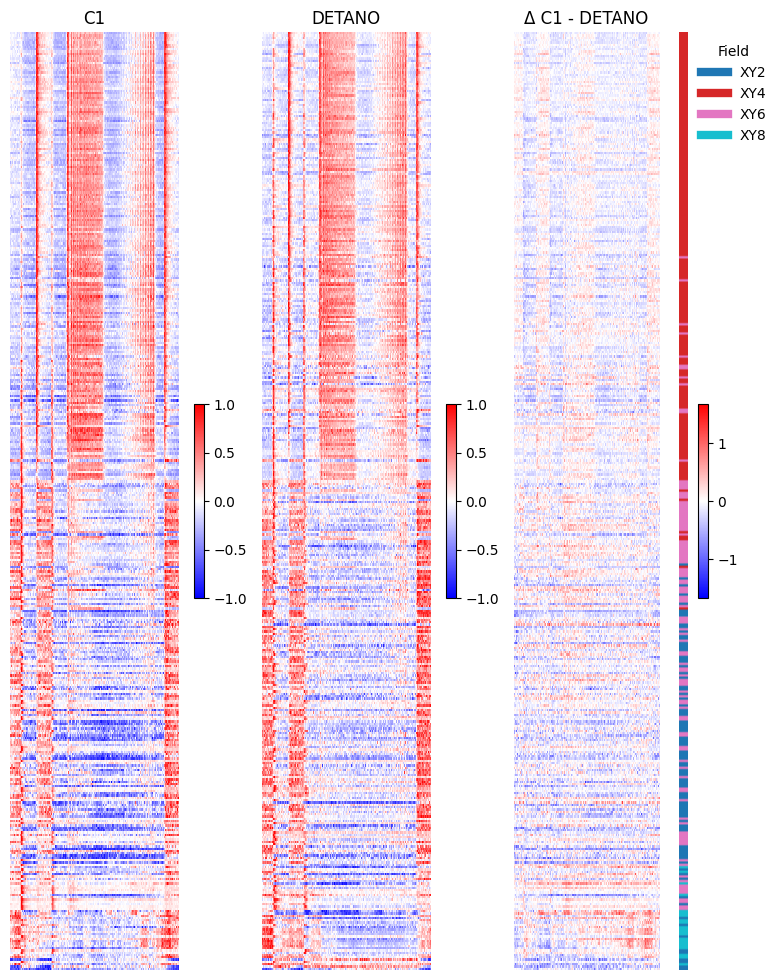

In [73]:
averages_norm_c1_minus_detano = averages_norm_c1[sort_idxs, :] - averages_norm_detano[sort_idxs, :]

fig, axs = plt.subplots(1, 3, figsize=(9, n * 0.03))

plot_signals_heatmap_annotated_field(
    signals=averages_norm_c1[sort_idxs, :],
    ax=axs[0],
    cb=True,
    field_labels=None,
    legend=False,
    heatmap_colorbar_position=0.08
)

plot_signals_heatmap_annotated_field(
    signals=averages_norm_detano[sort_idxs, :],
    ax=axs[1],
    cb=True,
    field_labels=None,
    legend=False,
    heatmap_colorbar_position=0.08
)

plot_signals_heatmap_annotated_field(
    signals=averages_norm_c1_minus_detano,
    ax=axs[2],
    cb=True,
    field_labels=fields_detano_sorted,
    legend=True,
    colorbar_width=0.05,
    heatmap_colorbar_position=0.2
)

axs[0].set_title("C1")
axs[1].set_title("DETANO")
axs[2].set_title("Δ C1 - DETANO")

plt.subplots_adjust(wspace=0.3)

plt.savefig("plots/20251023/traces/heatmap_gchirp_c1_and_detano.png",
            dpi=300,
            bbox_inches="tight")

# Local chirp

In [74]:
stimulus = "lChirp"

In [75]:
# Take chirp averages from 08.09.2025 + add quality index from same data
# To quickly filter for quality
lchirp_quality = (Averages() & {"date": date, "stim_name": stimulus}) * (ChirpQI() & {"date": date, "stim_name": stimulus})
lchirp_quality & "qidx > 0.3"

[2025-11-04 16:46:37,833][WARNING]: Reconnecting to MySQL server.


experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes,qidx quality index as signal to noise ratio,min_qidx minimum quality index as 1/r (r = #repetitions)
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,3,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.383134,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,5,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.316626,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,9,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.368321,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,10,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.364482,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,11,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.302005,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,13,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.366435,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,19,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.361466,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,20,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.381085,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,24,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.332875,0.2
Salomon,2025-10-23,1,1,XY7,LR,t,lChirp,C1,25,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.313142,0.2


In [77]:
# Filter for C1, C2, and DETANO + qidx > 0.3
C1_lchirp = lchirp_quality & {"cond2": "C1"} & "qidx > 0.3"
C2_lchirp = lchirp_quality & {"cond2": "C2"} & "qidx > 0.3"
DETANO_lchirp = lchirp_quality & {"cond2": "DETANO"} & "qidx > 0.3"

In [78]:
# Retrieve C1 recordings which also have a C2 recording
C1_and_C2_lchirp = C1_lchirp & (dj.U("field", "roi_id") & C2_lchirp)
C2_and_C1_lchirp = C2_lchirp & (dj.U("field", "roi_id") & C1_lchirp)
C1_and_DETANO_lchirp = C1_lchirp & (dj.U("field", "roi_id") & DETANO_lchirp)
DETANO_and_C1_lchirp = DETANO_lchirp & (dj.U("field", "roi_id") & C1_lchirp)

## C1 and C2
- compute heatmap of lchirp recording with C1 and C2

In [79]:
averages_norm_c1 = (C1_and_C2_lchirp).fetch("average_norm")
averages_norm_c2 = (C2_and_C1_lchirp).fetch("average_norm")

averages_norm_c1 = math_utils.padded_vstack(averages_norm_c1, cval=np.nan)
averages_norm_c2 = math_utils.padded_vstack(averages_norm_c2, cval=np.nan)

n = averages_norm_c1.shape[0]

sort = True

sort_idxs = trace_utils.argsort_traces(averages_norm_c1, ignore_nan=True) if sort else np.arange(n)

fields_c1 = (C1_and_C2_lchirp).fetch("field")
fields_c2 = (C2_and_C1_lchirp).fetch("field")

fields_c1_sorted = np.array(fields_c1)[sort_idxs]
fields_c2_sorted = np.array(fields_c2)[sort_idxs]

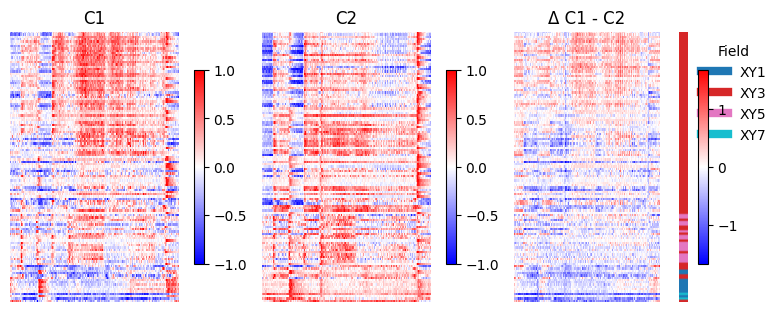

In [85]:
averages_norm_c1_minus_c2 = averages_norm_c1[sort_idxs, :] - averages_norm_c2[sort_idxs, :]

fig, axs = plt.subplots(1, 3, figsize=(9, n * 0.03))

plot_signals_heatmap_annotated_field(
    signals=averages_norm_c1[sort_idxs, :],
    ax=axs[0],
    cb=True,
    field_labels=None,
    legend=False,
    heatmap_colorbar_position=0.08
)

plot_signals_heatmap_annotated_field(
    signals=averages_norm_c2[sort_idxs, :],
    ax=axs[1],
    cb=True,
    field_labels=None,
    legend=False,
    heatmap_colorbar_position=0.08
)

plot_signals_heatmap_annotated_field(
    signals=averages_norm_c1_minus_c2,
    ax=axs[2],
    cb=True,
    field_labels=fields_c2_sorted,
    legend=True,
    colorbar_width=0.05,
    heatmap_colorbar_position=0.2
)

axs[0].set_title("C1")
axs[1].set_title("C2")
axs[2].set_title("Δ C1 - C2")

plt.subplots_adjust(wspace=0.3)

plt.savefig("plots/20251023/traces/heatmap_lchirp_c1_and_c2.png",
            dpi=300,
            bbox_inches="tight")

## C1 and DETANO
- compute heatmap of lchirp recording with C1 and DETA/NO

In [86]:
averages_norm_c1 = (C1_and_DETANO_lchirp).fetch("average_norm")
averages_norm_detano = (DETANO_and_C1_lchirp).fetch("average_norm")

averages_norm_c1 = math_utils.padded_vstack(averages_norm_c1, cval=np.nan)
averages_norm_detano = math_utils.padded_vstack(averages_norm_detano, cval=np.nan)

n = averages_norm_c1.shape[0]

sort = True

sort_idxs = trace_utils.argsort_traces(averages_norm_c1, ignore_nan=True) if sort else np.arange(n)

fields_c1 = (C1_and_DETANO_lchirp).fetch("field")
fields_detano = (DETANO_and_C1_lchirp).fetch("field")

fields_c1_sorted = np.array(fields_c1)[sort_idxs]
fields_detano_sorted = np.array(fields_detano)[sort_idxs]

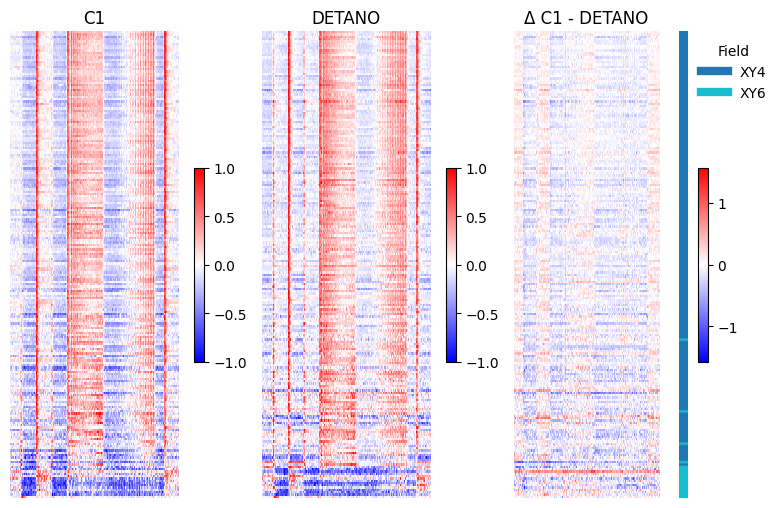

In [87]:
averages_norm_c1_minus_detano = averages_norm_c1[sort_idxs, :] - averages_norm_detano[sort_idxs, :]

fig, axs = plt.subplots(1, 3, figsize=(9, n * 0.03))

plot_signals_heatmap_annotated_field(
    signals=averages_norm_c1[sort_idxs, :],
    ax=axs[0],
    cb=True,
    field_labels=None,
    legend=False,
    heatmap_colorbar_position=0.08
)

plot_signals_heatmap_annotated_field(
    signals=averages_norm_detano[sort_idxs, :],
    ax=axs[1],
    cb=True,
    field_labels=None,
    legend=False,
    heatmap_colorbar_position=0.08
)

plot_signals_heatmap_annotated_field(
    signals=averages_norm_c1_minus_detano,
    ax=axs[2],
    cb=True,
    field_labels=fields_detano_sorted,
    legend=True,
    colorbar_width=0.05,
    heatmap_colorbar_position=0.2
)

axs[0].set_title("C1")
axs[1].set_title("DETANO")
axs[2].set_title("Δ C1 - DETANO")

plt.subplots_adjust(wspace=0.3)

plt.savefig("plots/20251023/traces/heatmap_lchirp_c1_and_detano.png",
            dpi=300,
            bbox_inches="tight")